In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv("spam.csv",encoding='windows-1252')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [5]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df['v1']=df['v1'].replace({'ham':0, 'spam':1})

C:\Users\ADmin\AppData\Local\Temp\ipykernel_18484\788310506.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['v1']=df['v1'].replace({'ham':0, 'spam':1})


In [7]:
df.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['v1'].value_counts()

v1
0    4825
1     747
Name: count, dtype: int64

In [9]:
df['v2'].isna().sum()

np.int64(0)

In [10]:
df['v1'].isnull().sum()

np.int64(0)

In [11]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

In [16]:
import nltk

In [17]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADmin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [18]:
nltk.data.path.append("C:/Users/ADmin/AppData/Roaming/nltk_data")

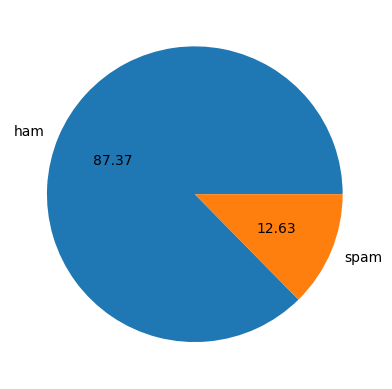

In [19]:
import matplotlib.pyplot as plt
plt.pie(df['v1'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [20]:
df['num_characters']=df['v2'].apply(len)

In [21]:
df.head(2)

,v1,v2,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29


In [22]:
from nltk.tokenize import TreebankWordTokenizer


tokenizer = TreebankWordTokenizer()
df['num_words'] = df['v2'].apply(lambda x: len(tokenizer.tokenize(x)))

In [23]:
df.head()

,v1,v2,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,23
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [24]:
import re

def simple_sentence_tokenize(text):
    # Split on ., !, or ? followed by space or end of string
    sentences = re.split(r'[.!?]+(?:\s|$)', text)
    return [s.strip() for s in sentences if s.strip()]

In [25]:
df['num_sentences']= df['v2'].apply(lambda x: len(simple_sentence_tokenize(x)))

In [26]:
df.head()

,v1,v2,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,23,3
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,36,2
3,0,U dun say so early hor... U c already then say...,49,13,2
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
## ham

df[df['v1']==0].describe()

,v1,num_characters,num_words,num_sentences
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459256,16.452613,1.916962
std,0.0,56.358207,12.858450,1.364464
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,21.000000,2.000000
max,0.0,910.000000,214.000000,31.000000


In [28]:
#spam

df[df['v1']==1].describe()

,v1,num_characters,num_words,num_sentences
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.891271,26.289433,3.055130
std,0.0,30.137753,6.579189,1.569463
min,1.0,13.000000,2.000000,1.000000
25%,1.0,132.000000,24.000000,2.000000
50%,1.0,149.000000,28.000000,3.000000
75%,1.0,157.000000,30.000000,4.000000
max,1.0,224.000000,41.000000,9.000000


In [29]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

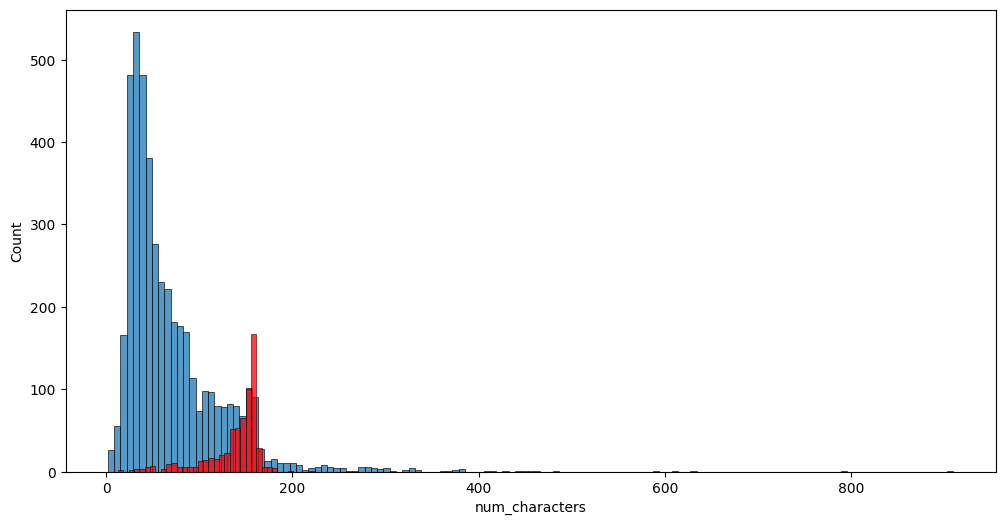

In [30]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['v1']==0]['num_characters'])
sns.histplot(df[df['v1']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

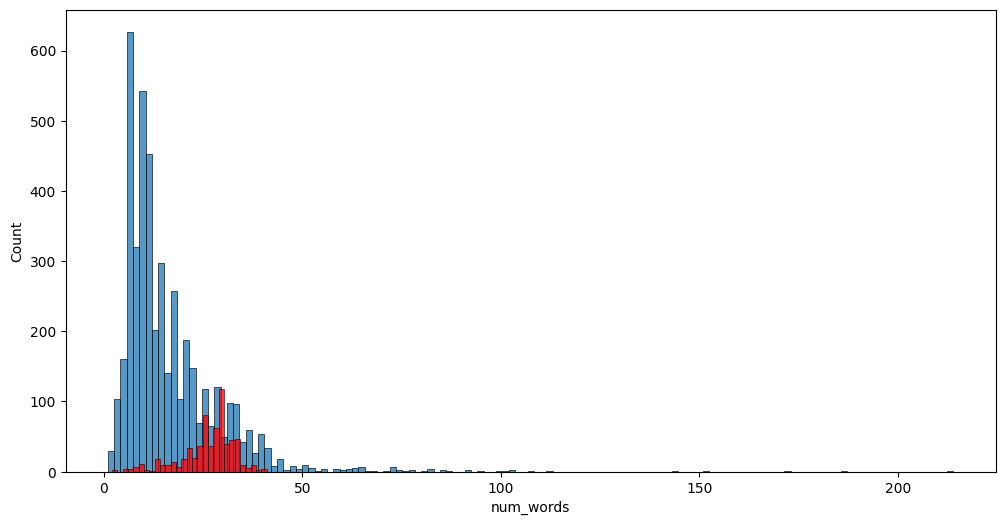

In [31]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['v1']==0]['num_words'])
sns.histplot(df[df['v1']==1]['num_words'],color='red')

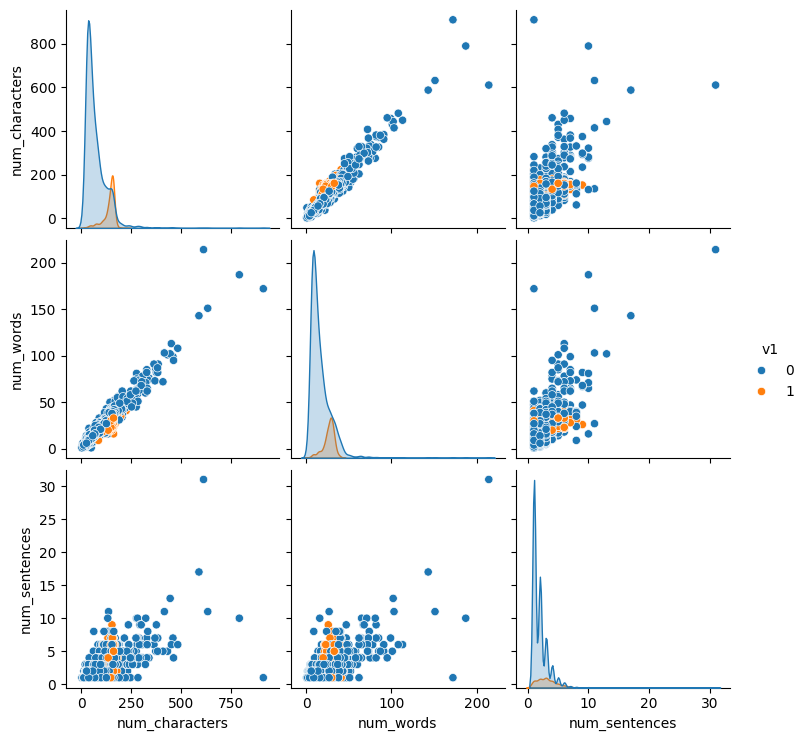

In [32]:
sns.pairplot(df,hue='v1')

## Data Preprocessing

In [33]:
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
stop_words = set(stopwords.words('english'))

def transform_text(text):
    
    
    text= text.lower()
    text=tokenizer.tokenize(text)

    y=[]

    for i in text:
        if i.isalnum():
            y.append(i)

    text= y[:]
    y.clear()

    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    stemmer = PorterStemmer()

    for i in text:
        y.append(stemmer.stem(i))

    return " ".join(y)   

 
    

In [34]:
df['transform_text']=df['v2'].apply(transform_text)

In [35]:
df.head(2)

,v1,v2,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,3,go jurong point avail bugi n great world la e ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [36]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [37]:
spam_wc = wc.generate(df[df['v1'] == 1]['transform_text'].str.cat(sep=" "))

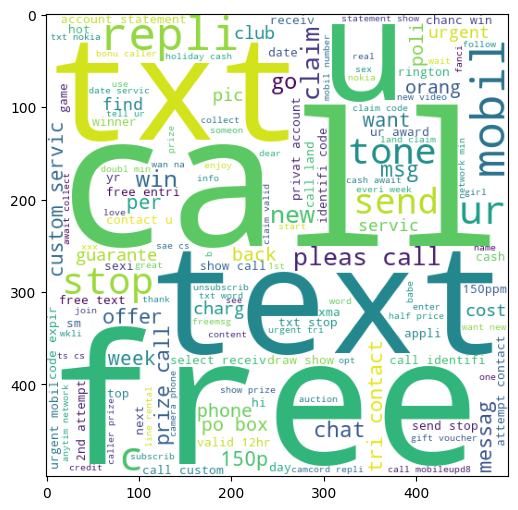

In [38]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [39]:
ham_wc = wc.generate(df[df['v1'] == 0]['transform_text'].str.cat(sep=" "))

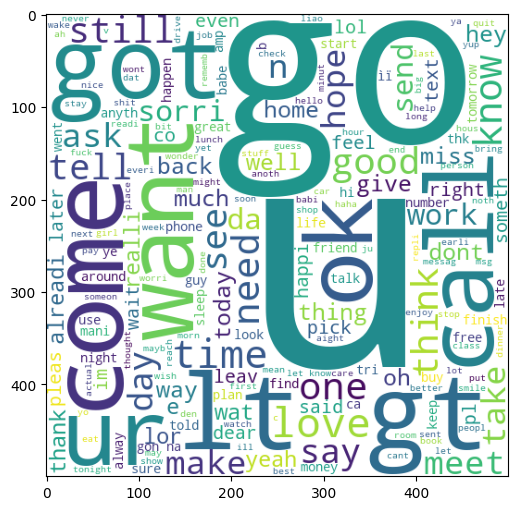

In [40]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [41]:
df.head(2)

,v1,v2,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,3,go jurong point avail bugi n great world la e ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [42]:
spam_corpus=[]

for msg in df[df['v1']==1]['transform_text'].tolist():
     
     for word in msg.split(" "):
          spam_corpus.append(word)

In [43]:
len(spam_corpus)

9339

C:\Users\ADmin\AppData\Local\Temp\ipykernel_18484\689660796.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=df_common, palette='viridis')


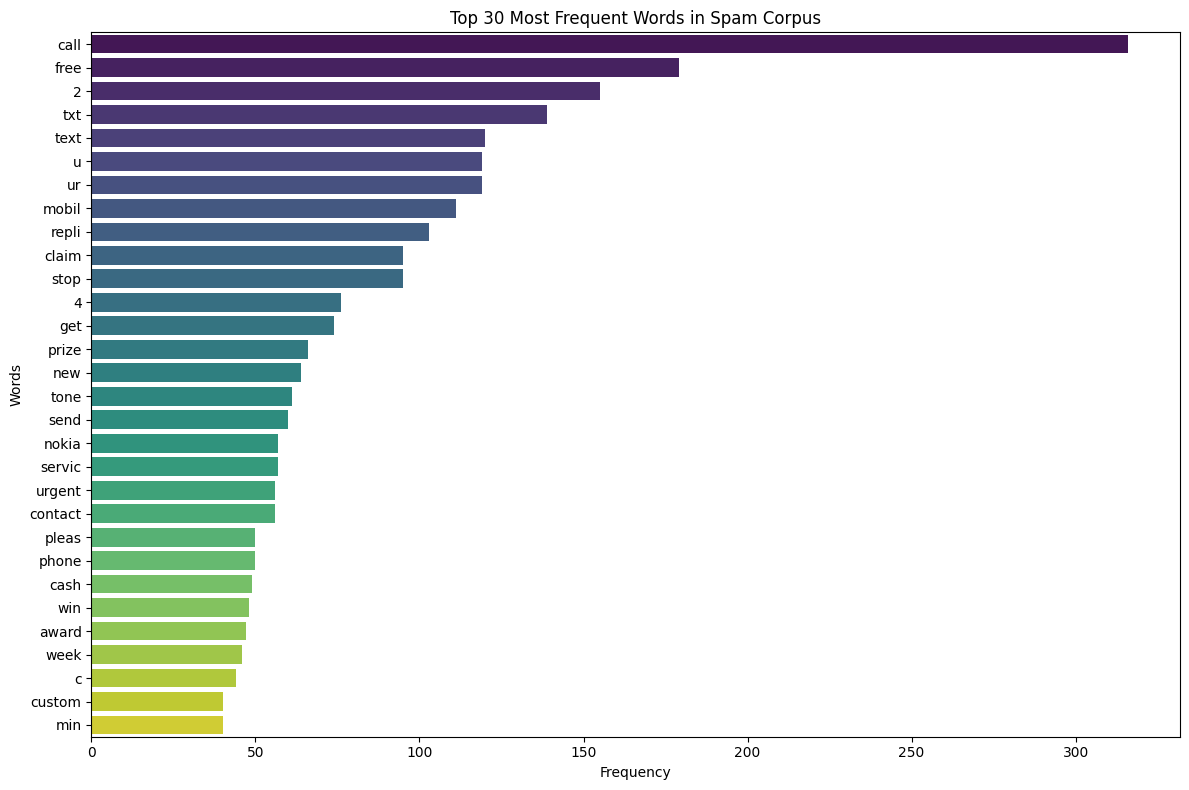

In [44]:
from collections import Counter

word_freq = Counter(spam_corpus).most_common(30)
df_common = pd.DataFrame(word_freq, columns=['word', 'count'])

# Step 2: Plot using seaborn barplot
plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='word', data=df_common, palette='viridis')
plt.title("Top 30 Most Frequent Words in Spam Corpus")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.tight_layout()
plt.show()

## modeling

In [45]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()

In [46]:
X=cv.fit_transform(df['transform_text']).toarray()

In [47]:
X.shape

(5169, 6355)

In [48]:
df.head(2)

,v1,v2,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,3,go jurong point avail bugi n great world la e ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni


In [49]:
y=df['v1'].values

In [50]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [51]:
from sklearn.model_selection import train_test_split


In [52]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [54]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [55]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8597678916827853
[[773 123]
 [ 22 116]]
0.48535564853556484


In [56]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9622823984526112
[[871  25]
 [ 14 124]]
0.8322147651006712


In [57]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9729206963249516
[[892   4]
 [ 24 114]]
0.9661016949152542


## TF-IDF

In [58]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=3000)

In [59]:
X=tfidf.fit_transform(df['transform_text']).toarray()

In [60]:
y = df['v1'].values

In [61]:
from sklearn.model_selection import train_test_split


In [62]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [63]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8568665377176016
[[774 122]
 [ 26 112]]
0.47863247863247865


In [64]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9700193423597679
[[896   0]
 [ 31 107]]
1.0


In [65]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9796905222437138
[[895   1]
 [ 20 118]]
0.9915966386554622


In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [67]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [68]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    
}

In [69]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [70]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9729206963249516, 0.9661016949152542)

In [71]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9661016949152542
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9700193423597679
Precision -  1.0
For  DT
Accuracy -  0.9294003868471954
Precision -  0.8282828282828283
For  LR
Accuracy -  0.9564796905222437
Precision -  0.9428571428571428
For  RF
Accuracy -  0.9748549323017408
Precision -  0.9912280701754386
For  AdaBoost
Accuracy -  0.9235976789168279
Precision -  0.8554216867469879
For  BgC
Accuracy -  0.960348162475822
Precision -  0.8646616541353384
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9590163934426229
For  GBDT
Accuracy -  0.9497098646034816
Precision -  0.9056603773584906


In [72]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [73]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970019,1.000000
5,RF,0.974855,0.991228
0,SVC,0.972921,0.966102
8,ETC,0.974855,0.959016
4,LR,0.956480,0.942857
9,GBDT,0.949710,0.905660
7,BgC,0.960348,0.864662
6,AdaBoost,0.923598,0.855422
3,DT,0.929400,0.828283


In [74]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [75]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970019
2,RF,Accuracy,0.974855
3,SVC,Accuracy,0.972921
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.956480
6,GBDT,Accuracy,0.949710
7,BgC,Accuracy,0.960348
8,AdaBoost,Accuracy,0.923598
9,DT,Accuracy,0.929400


In [76]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [77]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [78]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [79]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9787234042553191
Precision 0.9833333333333333


In [80]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [81]:
from sklearn.ensemble import StackingClassifier

In [82]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [83]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9758220502901354
Precision 0.9185185185185185


## we can still use min_max scaler and we can also use other feature like number_words, number_characters,.... so on..

In [85]:
import pickle
pickle.dump(tfidf, open("vectorizer.pkl", "wb"))
pickle.dump(mnb, open("model.pkl", "wb"))   
pickle.dump(clf, open("spam_model.pkl", "wb"))